In [1]:
import random
import torch
from d2l import torch as d2l

In [2]:
import math

def normal(x ,mu , sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma ** 2)
    return p * torch.exp(-0.5 / sigma ** 2 * (x - mu) ** 2)

## 3.2.1 生成数据集

In [3]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [4]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.5810,  0.1208]) 
label: tensor([2.6181])


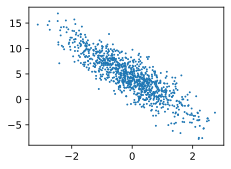

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

## 3.2.2 读取数据集

In [6]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [7]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.5826,  0.3936],
        [-1.2895, -0.9661],
        [-1.1290, -1.1039],
        [ 0.1985,  1.6299],
        [ 0.5084, -1.9239],
        [-1.3478, -0.8065],
        [ 2.3196,  1.3266],
        [ 0.1452,  0.5247],
        [-1.4764, -1.2426],
        [-0.2167, -0.2918]]) 
 tensor([[ 4.0317],
        [ 4.8969],
        [ 5.6909],
        [-0.9413],
        [11.7564],
        [ 4.2443],
        [ 4.2991],
        [ 2.7261],
        [ 5.4794],
        [ 4.7774]])


## 3.2.3 初始化模型参数

In [8]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

## 3.2.4 定义模型

In [9]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

## 3.2.5 定义损失函数

In [10]:
def square_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

## 3.2.6 定义优化算法

In [12]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 3.2.7 训练

In [13]:
lr = 0.03
num_epochs = 3
net = linreg
loss = square_loss

In [14]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.021209
epoch 2, loss 0.000074
epoch 3, loss 0.000048


In [15]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 2.1720e-04, -5.7459e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0002], grad_fn=<RsubBackward1>)
